# 03. Modelado y Comparación de Modelos

Este notebook se encarga de entrenar, evaluar y comparar múltiples modelos de regresión para predecir el porcentaje de sílice en el concentrado (`% Silica Concentrate`) utilizando los datos procesados en la etapa anterior.

## Modelos a evaluar:
1. **Regresión Lineal (Línea Base):** Un modelo lineal simple como punto de partida. Se requiere estandarización previa de características.
2. **Random Forest Regressor:** Un modelo de ensamble de árboles basado en bagging. Se configurará con parámetros de subsaneamiento para asegurar un entrenamiento eficiente en grandes volúmenes de datos.
3. **XGBoost Regressor:** Un modelo de gradient boosting altamente eficiente que suele ofrecer el mejor rendimiento predictivo en datos tabulares.

## Evitación de Target Leakage:
Se excluye la variable `% Iron Concentrate` del entrenamiento ya que es una variable de salida medida al final del proceso de flotación al mismo tiempo que la variable objetivo `% Silica Concentrate`. Su uso causaría fuga de información.

## Métricas de evaluación (en el set de prueba cronológico):
- **MAE** (Mean Absolute Error)
- **RMSE** (Root Mean Squared Error)
- **R²** (Coefficient of Determination)

In [ ]:
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configurar estilos de gráficos
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:
train_path = '../data/processed/train_engineered.parquet'
test_path = '../data/processed/test_engineered.parquet'

print("Cargando datos procesados...")
train_df = pd.read_parquet(train_path)
test_df = pd.read_parquet(test_path)

print(f"Dimensiones de entrenamiento: {train_df.shape}")
print(f"Dimensiones de prueba: {test_df.shape}")

Cargando datos procesados...


Dimensiones de entrenamiento: (589842, 120)
Dimensiones de prueba: (147600, 120)


In [ ]:
target_col = '% Silica Concentrate'
leakage_col = '% Iron Concentrate'
date_col = 'date'

# Las variables explicativas (features) serán todas menos el target, la columna de leakage y la fecha
feature_cols = [col for col in train_df.columns if col not in [target_col, leakage_col, date_col]]

print(f"Cantidad total de características a utilizar: {len(feature_cols)}")
print("\nPrimeras 5 características:")
print(feature_cols[:5])

# Separar X e y
X_train = train_df[feature_cols].copy()
y_train = train_df[target_col].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].copy()

print(f"\nX_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

Cantidad total de características a utilizar: 117

Primeras 5 características:
['% Iron Feed', '% Silica Feed', 'Starch Flow', 'Amina Flow', 'Ore Pulp Flow']



X_train: (589842, 117), y_train: (589842,)
X_test: (147600, 117), y_test: (147600,)


In [4]:
# La Regresión Lineal requiere escalado de variables para su correcto ajuste y convergencia estable
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Características estandarizadas para el modelo de Regresión Lineal.")

Características estandarizadas para el modelo de Regresión Lineal.


In [5]:
print("Entrenando Regresión Lineal...")
lr_model = LinearRegression(n_jobs=-1)
lr_model.fit(X_train_scaled, y_train)

# Predicciones
y_pred_lr = lr_model.predict(X_test_scaled)

# Métricas
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("\n--- Regresión Lineal (Línea Base) ---")
print(f"MAE:  {mae_lr:.4f}")
print(f"RMSE: {rmse_lr:.4f}")
print(f"R²:   {r2_lr:.4f}")

Entrenando Regresión Lineal...



--- Regresión Lineal (Línea Base) ---
MAE:  0.9420
RMSE: 1.2015
R²:   -0.1014


In [6]:
print("Entrenando Random Forest Regressor (con parámetros optimizados para velocidad)...")
# Usamos max_samples=0.1 para que cada árbol use solo el 10% del dataset (~59,000 registros),
# y max_depth=12 para controlar el tamaño de los árboles y evitar sobreajuste y lentitud.
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    max_samples=0.1,
    n_jobs=-1,
    random_state=42
)
rf_model.fit(X_train, y_train)

# Predicciones
y_pred_rf = rf_model.predict(X_test)

# Métricas
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("\n--- Random Forest Regressor ---")
print(f"MAE:  {mae_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"R²:   {r2_rf:.4f}")

Entrenando Random Forest Regressor (con parámetros optimizados para velocidad)...



--- Random Forest Regressor ---
MAE:  0.9490
RMSE: 1.1726
R²:   -0.0492


In [7]:
print("Entrenando XGBoost Regressor...")
# tree_method='hist' permite un entrenamiento muy rápido en conjuntos de datos grandes
xgb_model = XGBRegressor(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1,
    tree_method='hist',
    n_jobs=-1,
    random_state=42
)
xgb_model.fit(X_train, y_train)

# Predicciones
y_pred_xgb = xgb_model.predict(X_test)

# Métricas
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("\n--- XGBoost Regressor ---")
print(f"MAE:  {mae_xgb:.4f}")
print(f"RMSE: {rmse_xgb:.4f}")
print(f"R²:   {r2_xgb:.4f}")

Entrenando XGBoost Regressor...



--- XGBoost Regressor ---
MAE:  0.9276
RMSE: 1.1775
R²:   -0.0579


Tabla comparativa de rendimiento:
              Modelo       MAE      RMSE        R²
0  Linear Regression  0.941980  1.201462 -0.101369
1      Random Forest  0.948979  1.172648 -0.049176
2            XGBoost  0.927603  1.177541 -0.057949


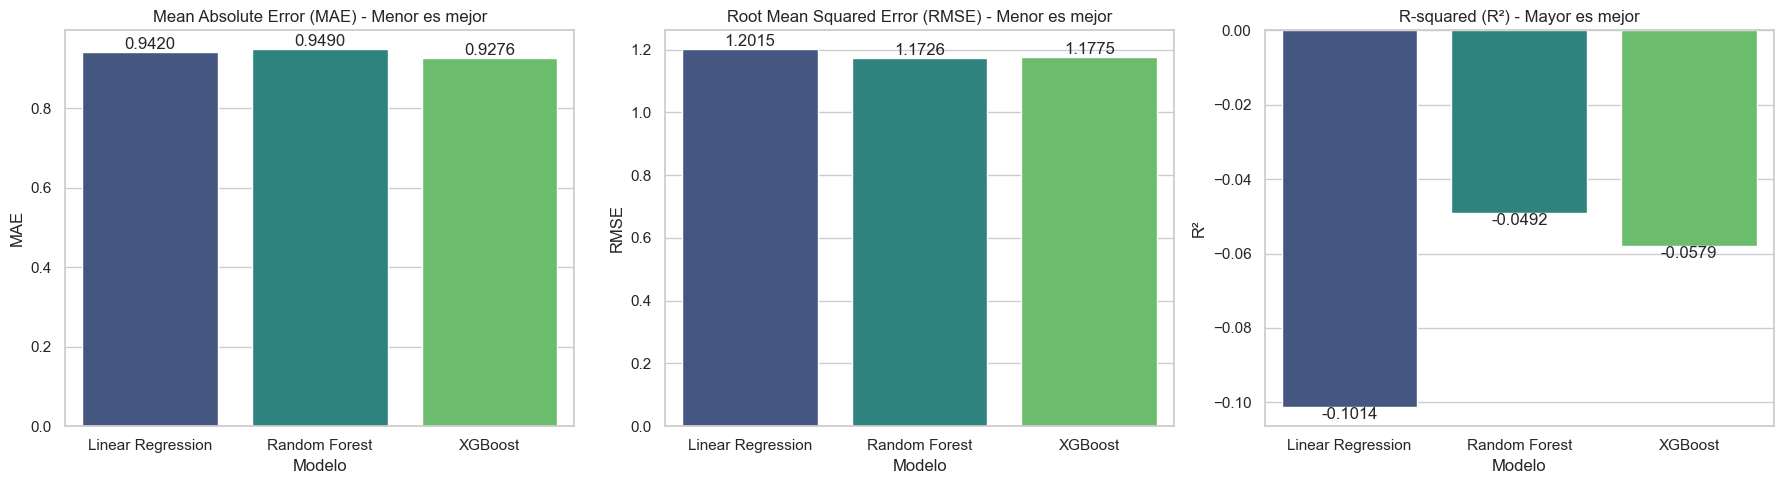

In [8]:
# Crear DataFrame con los resultados
results_df = pd.DataFrame({
    'Modelo': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'MAE': [mae_lr, mae_rf, mae_xgb],
    'RMSE': [rmse_lr, rmse_rf, rmse_xgb],
    'R²': [r2_lr, r2_rf, r2_xgb]
})

print("Tabla comparativa de rendimiento:")
print(results_df)

# Graficar resultados
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# MAE
sns.barplot(x='Modelo', y='MAE', data=results_df, ax=axes[0], hue='Modelo', legend=False, palette='viridis')
axes[0].set_title('Mean Absolute Error (MAE) - Menor es mejor')
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.4f')

# RMSE
sns.barplot(x='Modelo', y='RMSE', data=results_df, ax=axes[1], hue='Modelo', legend=False, palette='viridis')
axes[1].set_title('Root Mean Squared Error (RMSE) - Menor es mejor')
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.4f')

# R²
sns.barplot(x='Modelo', y='R²', data=results_df, ax=axes[2], hue='Modelo', legend=False, palette='viridis')
axes[2].set_title('R-squared (R²) - Mayor es mejor')
for container in axes[2].containers:
    axes[2].bar_label(container, fmt='%.4f')

plt.tight_layout()
os.makedirs('../reports/figuras', exist_ok=True)
plt.savefig('../reports/figuras/comparacion_modelos.png', dpi=300)
plt.show()

In [ ]:
# Crear directorio models/ si no existe
os.makedirs('../models', exist_ok=True)

# Encontrar el mejor modelo según R² en test
best_idx = results_df['R²'].idxmax()
best_model_name = results_df.loc[best_idx, 'Modelo']
print(f"El mejor modelo basado en R² en el conjunto de prueba es: {best_model_name}")

if best_model_name == 'Linear Regression':
    best_model_obj = {
        'model': lr_model,
        'scaler': scaler,
        'features': feature_cols
    }
elif best_model_name == 'Random Forest':
    best_model_obj = {
        'model': rf_model,
        'features': feature_cols
    }
else:  # XGBoost
    best_model_obj = {
        'model': xgb_model,
        'features': feature_cols
    }

model_save_path = '../models/best_model.joblib'
print(f"Guardando el mejor modelo en: {model_save_path}...")
joblib.dump(best_model_obj, model_save_path)
print("¡Modelo guardado exitosamente!")

El mejor modelo basado en R² en el conjunto de prueba es: Random Forest
Guardando el mejor modelo en: ../models/best_model.joblib...


¡Modelo guardado exitosamente!
